Python import statements 

In [1]:
import PIL.Image as image 
import numpy as np 
import matplotlib.pyplot as plt 

Load a image and show the orginal image

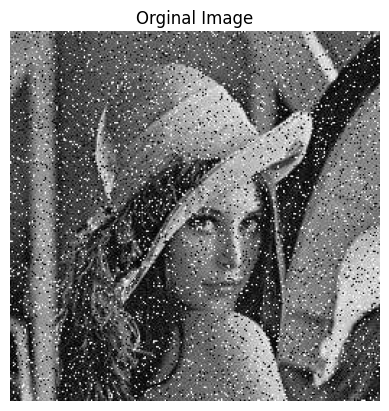

In [9]:
img = image.open("Images/noise_img.png").convert("L")
img_array = np.array(img)

plt.imshow(img_array, cmap="gray")
plt.title("Orginal Image")
plt.axis("off")

plt.show()

Image Height and Width using shape

In [10]:
H, W = img_array.shape

3×3 filtering metrix

In [11]:
filter = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
])

Use replicate padding (edge padding) to handle boundary pixels

In [12]:
padded_img = np.pad(img_array, pad_width=1, mode="edge")

Apply a 3×3 averaging filter to smooth the image

In [13]:
mean_result = np.zeros_like(img_array)

for i in range(H):
    for j in range(W):
        region = padded_img[i : i + 3, j : j + 3]
        mean_result[i, j] = np.sum(region * filter)

Apply a 3×3 median filter to smooth the image

In [14]:
median_result = np.zeros_like(img_array)

for i in range(H):
    for j in range(W):
        region = padded_img[i : i + 3, j : j + 3]
        median_result[i, j] = np.median(region)

Display the Original image, Averaging filter output, and Median filter outpu

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

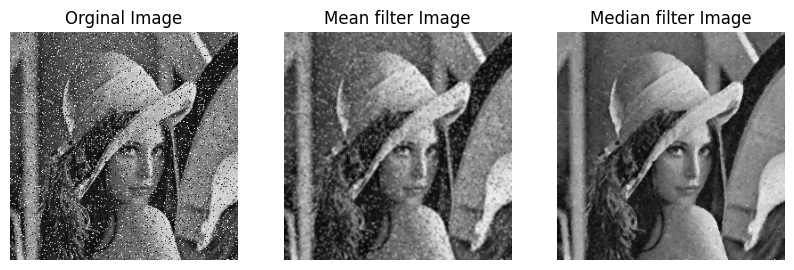

In [16]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_array, cmap="gray")
plt.title("Orginal Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mean_result, cmap="gray")
plt.title("Mean filter Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(median_result, cmap="gray")
plt.title("Median filter Image")
plt.axis("off")